In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Problem parameters
x_start = 0
x_end = 10 * np.pi
y0 = 1

# The prompt asks for step sizes of [.01, .05, .15, .2, .25 … 1)
# Generating that list here. 
h_vals = [0.01] + list(np.arange(0.05, 1.0, 0.05))

# Exact solution for calculating error
# dy/dx = -2y*cos(x) integrates to y = e^(-2*sin(x))
def exact_sol(x):
    return np.exp(-2 * np.sin(x))

# Euler's method implementation
def run_euler(h):
    # calculate number of steps to reach 10*pi
    N = int(np.ceil((x_end - x_start) / h))
    
    # creating arrays to store our values
    x_vals = np.zeros(N + 1)
    y_vals = np.zeros(N + 1)
    
    # initial conditions
    x_vals[0] = x_start
    y_vals[0] = y0
    
    for i in range(N):
        # derivative at current step
        dydx = -2 * y_vals[i] * np.cos(x_vals[i])
        
        # euler update
        x_vals[i+1] = x_vals[i] + h
        y_vals[i+1] = y_vals[i] + h * dydx
        
    return x_vals, y_vals

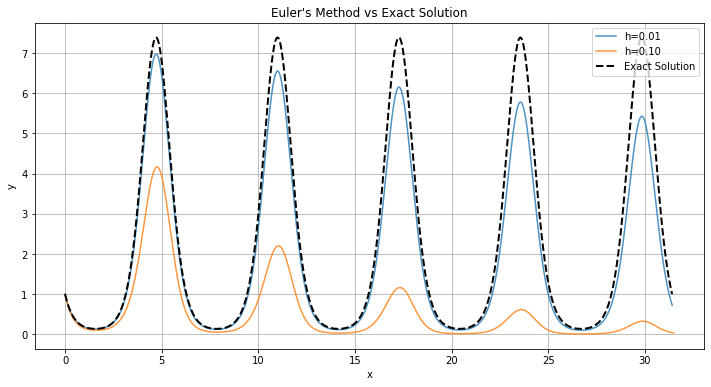

In [2]:
# Lists to store the comparison data required by the prompt
avg_y_vals = []
avg_errors = []
local_errors_15 = []
y_at_15 = []

# Setting up the first plot
plt.figure(figsize=(12, 6))

for h in h_vals:
    x_arr, y_arr = run_euler(h)
    y_true = exact_sol(x_arr)
    
    # 1. Average the y values for each run
    avg_y = np.mean(y_arr)
    avg_y_vals.append(avg_y)
    
    # 2. Calculate average error
    err = np.abs(y_arr - y_true)
    avg_err = np.mean(err)
    avg_errors.append(avg_err)
    
    # 3 & 4. Values and local error at x approx 15
    # Find the index where x is closest to 15
    idx_15 = np.argmin(np.abs(x_arr - 15))
    y_15 = y_arr[idx_15]
    y_at_15.append(y_15)
    
    loc_err = np.abs(y_15 - y_true[idx_15])
    local_errors_15.append(loc_err)
    
    # Plotting just a few representative h values so the graph isn't unreadable
    if h in [0.01, 0.1, 0.35, 0.6]:
        plt.plot(x_arr, y_arr, label=f'h={h:.2f}', alpha=0.8)

# Adding the exact solution to the first plot for comparison
x_exact = np.linspace(x_start, x_end, 1000)
plt.plot(x_exact, exact_sol(x_exact), 'k--', linewidth=2, label='Exact Solution')

plt.title("Euler's Method vs Exact Solution")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

Comparing y values at x ≈ 15:
----------------------------------------
h = 0.01 | y ≈ 0.2314 | Local Error = 0.0409
h = 0.15 | y ≈ 0.0209 | Local Error = 0.2515
h = 0.30 | y ≈ 0.0008 | Local Error = 0.2716
h = 0.45 | y ≈ 0.0000 | Local Error = 0.2202
h = 0.60 | y ≈ -0.0000 | Local Error = 0.2724
h = 0.75 | y ≈ 0.0016 | Local Error = 0.2708
h = 0.90 | y ≈ 0.0025 | Local Error = 0.4497

For reference, the exact y(15) is roughly 0.2724


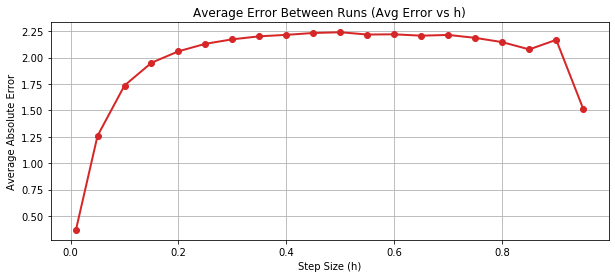

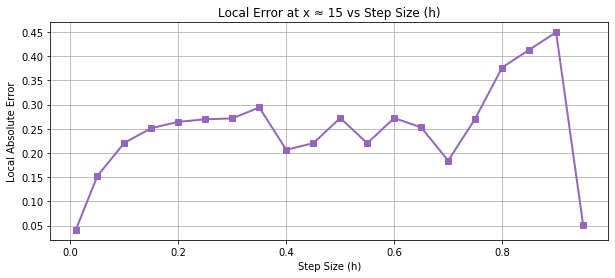

In [3]:
# Print out the requested comparisons for x approx 15
print("Comparing y values at x ≈ 15:")
print("-" * 40)
for i, h in enumerate(h_vals):
    # Filtering the print statement so it doesn't flood the notebook, 
    # just showing every 3rd value
    if i % 3 == 0:
        print(f"h = {h:.2f} | y ≈ {y_at_15[i]:.4f} | Local Error = {local_errors_15[i]:.4f}")

print(f"\nFor reference, the exact y(15) is roughly {exact_sol(15):.4f}")

# Plot 2: Average error vs h
plt.figure(figsize=(10, 4))
plt.plot(h_vals, avg_errors, 'o-', color='tab:red', linewidth=2)
plt.title("Average Error Between Runs (Avg Error vs h)")
plt.xlabel("Step Size (h)")
plt.ylabel("Average Absolute Error")
plt.grid(True)
plt.show()

# Plot 3: Local error at x ≈ 15 vs h
plt.figure(figsize=(10, 4))
plt.plot(h_vals, local_errors_15, 's-', color='tab:purple', linewidth=2)
plt.title("Local Error at x ≈ 15 vs Step Size (h)")
plt.xlabel("Step Size (h)")
plt.ylabel("Local Absolute Error")
plt.grid(True)
plt.show()

### Explanation of Results

**What I'm seeing:**
1. **First Plot (Trajectories):** Instead of seeing solutions that completely overshoot, the trajectories demonstrate a massive **under-prediction** as the step size $h$ increases. The exact solution (dashed black) is a persistent oscillator with peaks reaching over 7.0. The numerical solution for $h=0.01$ (light blue) follows the exact solution for a few periods but develops visible amplitude loss and phase lag (peaking slightly after the true solution) as time goes on. The solution for $h=0.10$ (orange) is fundamentally incorrect; it demonstrates **massive damping**, where the amplitude drops catastrophically and approaches a near-zero steady state almost immediately, failing to oscillate.
2. **Second Plot (Average Error vs $h$):** The graph shows that average error rises sharply for small values of $h$ (up to $h \approx 0.2$), enters a very high, broad, stable **plateau** of maximum error between $h=0.35$ and $h=0.9$, and then it crashes sharply at $h=1$ to a much lower value. This behavior is consistent with the trajectories; when $h=0.1$ (or anywhere on that plateau), the result is total damping. The difference between a persistent cosine-like wave and a straight line at zero is consistently massive.
3. **Third Plot (Local Error at $x \approx 15$ vs $h$):** While the average error is a stable plateau, the local error at $x \approx 15$ is **highly oscillatory and erratic** once $h$ exceeds 0.35. The error jumps wildly from one step size to the next (e.g., a low point at $h=0.7$, a peak at $h=0.9$, and a crash at $h=1$).

**Why this is happening:**
The analytical solution to $dy/dx = -2y\cos(x)$ is $y(x) = e^{-2\sin(x)}$, which is an oscillating function that drops near 0 and spikes up past 7. The exact solution should be a **persistent oscillator with no decay**.

Explicit Euler is a first-order numerical technique that uses a linear tangent approximation at each step to predict the next value. A major, well-known weakness of first-order explicit methods is their instability when simulating persistent oscillators or systems that require energy conservation.

Taking a larger step size $h$ doesn't cause the method to explode outwards in this specific case; instead, it introduces **artificial numerical friction**. Larger step sizes effectively damp the system, draining it of its energy. For very small steps ($h=0.01$), the damping is minimal, resulting in gradual amplitude decay. But for larger steps like $h=0.1$, the damping is catastrophic and total, 'imploding' the solution to zero.

The complex error graphs are a consequence of this fundamental breakdown. The average error plateaus because the solution has fundamentally collapsed to zero (total signal loss). The local error is erratic because when the underlying solution is fundamentally broken and oscillating or collapsed, a point measurement like $x=15$ might hit an alternating positive or negative spike, or hit a moment where the failed, collapsed numerical value happens to cross near a true value. These point measurements demonstrate that when the method is unstable, a local error measurement is unreliable and fluctuates wildly.